<Axes: >

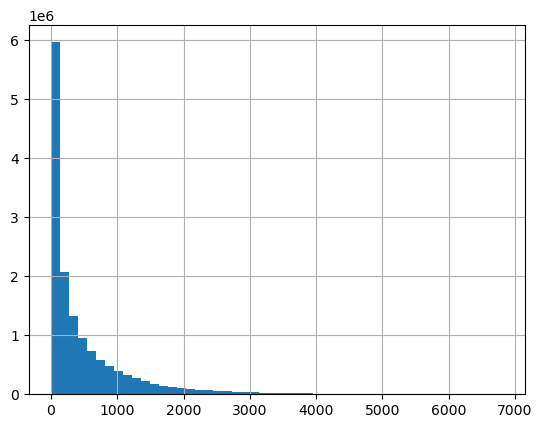

In [2]:
import pandas as pd

df = pd.read_parquet(
    r"C:\Users\lola\github\p04_golez_jackwerth_2024\_data\optionm_spx_options.parquet")


df["mid_price"].hist(bins=50)


In [4]:
from pathlib import Path

DATA_DIR = Path(r"C:\Users\lola\github\p04_golez_jackwerth_2024\_data")


In [6]:
import pandas as pd

crsp_msix = pd.read_parquet(DATA_DIR / "CRSP_MSIX.parquet")
crsp_msf_inputs = pd.read_parquet(DATA_DIR / "CRSP_MSF_INDEX_INPUTS.parquet")

sp500_daily = pd.read_parquet(DATA_DIR / "crsp_sp500_daily.parquet")

treasury_returns = pd.read_parquet(DATA_DIR / "crsp_treasury_returns.parquet")

fred_rates = pd.read_parquet(DATA_DIR / "fred_treasury_rates.parquet")
fred = pd.read_parquet(DATA_DIR / "fred.parquet")

options = pd.read_parquet(DATA_DIR / "optionm_spx_options.parquet")



In [7]:
for name, df in {
    "CRSP_MSIX": crsp_msix,
    "SP500 daily": sp500_daily,
    "Treasury returns": treasury_returns,
    "FRED rates": fred_rates,
    "Options": options
}.items():
    print(f"{name:20s} | shape = {df.shape}")


CRSP_MSIX            | shape = (1189, 35)
SP500 daily          | shape = (26051, 4)
Treasury returns     | shape = (1189, 3)
FRED rates           | shape = (16436, 4)
Options              | shape = (14482953, 12)


In [10]:
import numpy as np
import pandas as pd

crsp_msix["caldt"] = pd.to_datetime(crsp_msix["caldt"])
crsp_msix = crsp_msix.set_index("caldt").sort_index()



In [11]:
mkt_log = np.log1p(crsp_msix["vwretd"])


In [12]:
strip_log = np.log1p(crsp_msix["decret1"])


In [13]:
def summary_stats(log_ret):
    ann_mean = log_ret.mean() * 12 * 100
    ann_std = log_ret.std() * np.sqrt(12) * 100
    sharpe = ann_mean / ann_std
    ar1 = log_ret.autocorr(lag=1)
    n = log_ret.dropna().shape[0]
    
    return pd.Series({
        "Mean (%)": ann_mean,
        "Std. dev. (%)": ann_std,
        "Sharpe ratio": sharpe,
        "AR(1)": ar1,
        "N": n
    })


In [14]:
table1_raw = pd.DataFrame({
    "Market": summary_stats(mkt_log),
    "Strip": summary_stats(strip_log)
})

table1_raw


,Market,Strip
Mean (%),9.528250,13.930900
Std. dev. (%),18.415876,32.372347
Sharpe ratio,0.517393,0.430333
AR(1),0.087666,0.170424
N,1188.000000,1188.000000


<Axes: title={'center': 'Cumulative Returns: Market vs Dividend Strip'}, xlabel='caldt'>

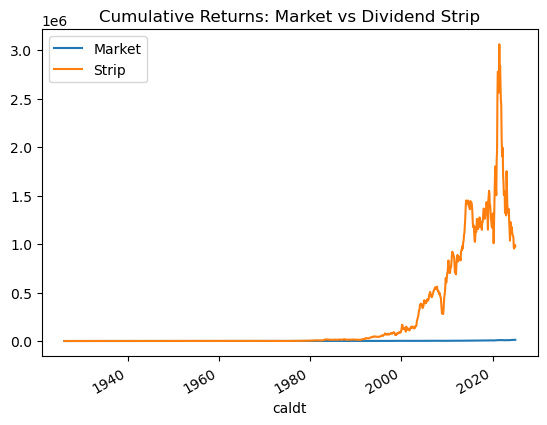

In [15]:
cum_mkt = np.exp(mkt_log.cumsum())
cum_strip = np.exp(strip_log.cumsum())

cum_df = pd.DataFrame({
    "Market": cum_mkt,
    "Strip": cum_strip
})

cum_df.plot(title="Cumulative Returns: Market vs Dividend Strip")


Rolling volatility

<Axes: title={'center': '12-Month Rolling Annualized Volatility'}, xlabel='caldt'>

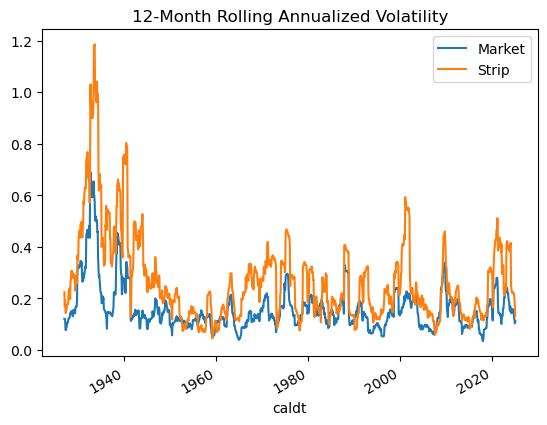

In [16]:
rolling_vol = pd.DataFrame({
    "Market": mkt_log.rolling(12).std() * np.sqrt(12),
    "Strip": strip_log.rolling(12).std() * np.sqrt(12),
})

rolling_vol.plot(title="12-Month Rolling Annualized Volatility")


In [17]:
crsp_msix["vwretd"].describe()


count    1188.000000
mean        0.009384
std         0.053178
min        -0.291731
25%        -0.018313
50%         0.013001
75%         0.039376
max         0.394143
Name: vwretd, dtype: float64

In [18]:
crsp_msix["vwretd"].head(10)


caldt
1925-12-31         NaN
1926-01-30    0.000561
1926-02-27   -0.033046
1926-03-31   -0.064002
1926-04-30    0.037029
1926-05-28    0.012095
1926-06-30    0.053664
1926-07-31    0.031411
1926-08-31    0.028647
1926-09-30    0.005787
Name: vwretd, dtype: float64

In [19]:
mkt_log.index[:5], strip_log.index[:5]


(DatetimeIndex(['1925-12-31', '1926-01-30', '1926-02-27', '1926-03-31',
                '1926-04-30'],
               dtype='datetime64[ns]', name='caldt', freq=None),
 DatetimeIndex(['1925-12-31', '1926-01-30', '1926-02-27', '1926-03-31',
                '1926-04-30'],
               dtype='datetime64[ns]', name='caldt', freq=None))

In [20]:
(mkt_log.index == strip_log.index).all()


True

<Axes: title={'center': 'Market cumulative return'}, xlabel='caldt'>

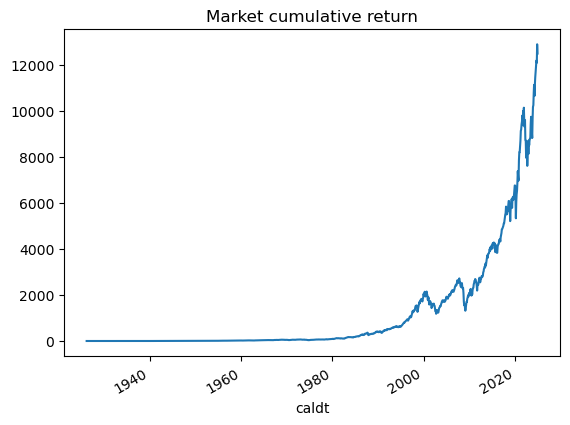

In [21]:
cum_df["Market"].plot(title="Market cumulative return")


<Axes: title={'center': 'Dividend Strip cumulative return'}, xlabel='caldt'>

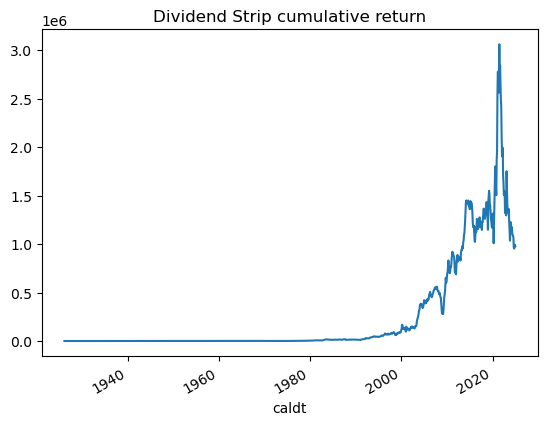

In [22]:
cum_df["Strip"].plot(title="Dividend Strip cumulative return")


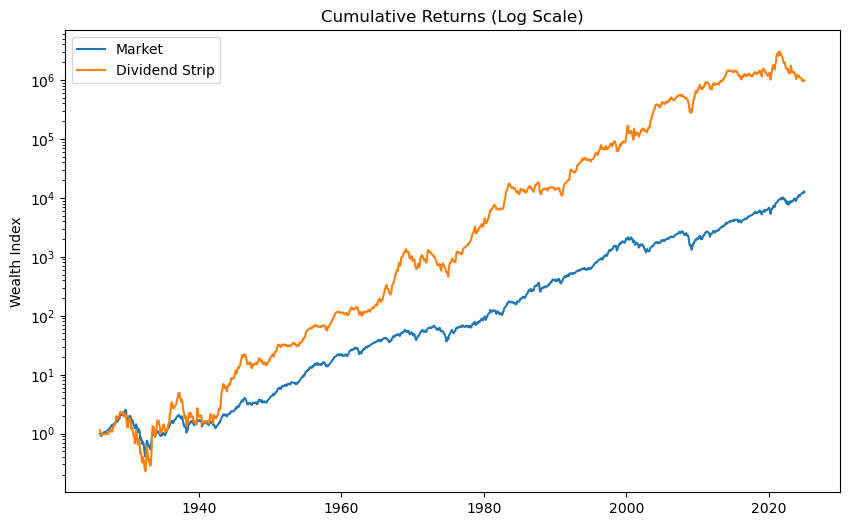

In [23]:
plt.figure(figsize=(10,6))
plt.plot(cum_df.index, cum_df["Market"], label="Market")
plt.plot(cum_df.index, cum_df["Strip"], label="Dividend Strip")
plt.yscale("log")
plt.legend()
plt.title("Cumulative Returns (Log Scale)")
plt.ylabel("Wealth Index")
plt.show()
